# Ramp-Verifikation: Trockenlauf ohne RIFE

Dieses Notebook entspricht **Schritt 7** unserer Pipeline-Anleitung: Wir berechnen die Timing-Tabelle für ein gegebenes Ramp-Preset und prüfen sie visuell sowie automatisiert auf physikalische Plausibilität, **bevor** wir Rechenzeit in RIFE-Interpolation und Motion-Blur-Rendering investieren.

**Workflow:**
1. Ramp-Preset laden
2. Timing-Tabelle berechnen
3. Automatisierte Plausibilitätsprüfung (Konsolen-Report)
4. Visuelle Verifikation (5-Panel-Plot)
5. Erst bei grünem Licht: weiter zu Schritt 8 (voller RIFE-Durchlauf)

In [1]:
# Projekt-Root zum Python-Pfad hinzufügen, damit die src/-Module importierbar sind.
# Annahme: Dieses Notebook liegt unter notebooks/, daher eine Ebene nach oben.
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))
print(f"Projekt-Root: {PROJECT_ROOT}")

Projekt-Root: c:\Daten Simon\HDM Master\Masterprojekt\framerate-ramp-pipeline


In [2]:
from src.ramp_curve import RampCurve
from src.timing_table import TimingTableBuilder
from src.utils.validation import run_all_checks, print_validation_report
from src.utils.ramp_plotting import build_full_verification_figure, save_and_show

%matplotlib inline

## 1) Konfiguration für diesen Testlauf

Hier die Parameter für den jeweiligen Clip anpassen. `max_source_frame_idx` entspricht der Anzahl tatsächlich extrahierter Quell-Frames minus 1 -- wichtig für die Indexgrenzen-Prüfung.

In [3]:
CLIP_ID = "clip_001"
PRESET_NAME = "25_100_25_smoothstep"
SOURCE_FPS = 100.0
OUTPUT_FPS = 25.0
TOTAL_DURATION_SEC = 4.5

# Anzahl tatsächlich extrahierter Frames in data/source_100fps/<clip>/frames/
# Falls die Frames noch nicht extrahiert sind: vorerst auf einen Schätzwert
# setzen (z.B. total_duration_sec * source_fps), um die Kurven-Logik isoliert
# zu testen -- die Indexgrenzen-Prüfung schlägt dann ggf. fehl, was hier okay ist.
MAX_SOURCE_FRAME_IDX = int(TOTAL_DURATION_SEC * SOURCE_FPS) - 1

preset_path = PROJECT_ROOT / "config" / "ramp_presets" / f"{PRESET_NAME}.json"
print(f"Preset-Pfad: {preset_path}")
print(f"Existiert: {preset_path.exists()}")

Preset-Pfad: c:\Daten Simon\HDM Master\Masterprojekt\framerate-ramp-pipeline\config\ramp_presets\25_100_25_smoothstep.json
Existiert: True


## 2) Ramp-Kurve laden und Timing-Tabelle berechnen

In [4]:
ramp = RampCurve.from_json(str(preset_path))

builder = TimingTableBuilder(ramp, source_fps=SOURCE_FPS, output_fps=OUTPUT_FPS)
timing_df = builder.build(total_duration_sec=TOTAL_DURATION_SEC)

print(f"Anzahl Output-Frames: {len(timing_df)}")
timing_df.head(10)

Anzahl Output-Frames: 112


,output_frame_idx,output_time_sec,source_time_sec,source_frame_floor,source_frame_ceil,rife_timestep,local_target_fps
0,0,0.00,0.000000,0,1,0.000000,25.000000
1,1,0.04,0.010000,1,2,0.000000,25.013659
2,2,0.08,0.020005,2,3,0.000546,25.104870
3,3,0.12,0.030047,3,4,0.004741,25.339395
4,4,0.16,0.040183,4,5,0.018317,25.770800
5,5,0.20,0.050491,5,6,0.049149,26.441185
6,6,0.24,0.061068,6,7,0.106796,27.381906
7,7,0.28,0.072021,7,8,0.202073,28.614307
8,8,0.32,0.083466,8,9,0.346645,30.150450
9,9,0.36,0.095527,9,10,0.552663,31.993838


In [5]:
# Timing-Tabelle speichern -- dies ist das zentrale Edit-Decision-Artefakt,
# das spätere Schritte (RIFE, Motion Blur, Reassembly) konsumieren.
interim_dir = PROJECT_ROOT / "data" / "interim" / CLIP_ID / f"ramp_{PRESET_NAME}"
interim_dir.mkdir(parents=True, exist_ok=True)

timing_csv_path = interim_dir / "timing_table.csv"
builder.save(timing_df, str(timing_csv_path))
print(f"Gespeichert: {timing_csv_path}")

Gespeichert: c:\Daten Simon\HDM Master\Masterprojekt\framerate-ramp-pipeline\data\interim\clip_001\ramp_25_100_25_smoothstep\timing_table.csv


## 3) Automatisierte Plausibilitätsprüfung

Diese Prüfungen laufen vor JEDEM Render-Start. Bei einem `FEHLER` in der Ausgabe: **nicht weitermachen**, sondern die Ursache beheben (siehe Klartext-Begründung pro Check).

In [6]:
results = run_all_checks(
    timing_df,
    max_source_frame_idx=MAX_SOURCE_FRAME_IDX,
    source_fps=SOURCE_FPS,
)
all_passed = print_validation_report(results)

PLAUSIBILITÄTSPRÜFUNG DER TIMING-TABLE
[OK] Monotonie der Quellzeit: source_time_sec ist durchgehend monoton steigend -- keine Zeitsprünge rückwärts.
[OK] Timestep-Wertebereich: Alle 112 Timesteps liegen korrekt in [0, 1). Min=0.0000, Max=0.9981.
[OK] Quell-Frame-Indexgrenzen: Maximal benötigter Quell-Frame-Index (336) liegt innerhalb der verfügbaren Sequenz (0..449).
[OK] Glattheit der FPS-Kurve (Sprung-Erkennung via 3. Ableitung): Keine isolierten Ruck-Spitzen erkannt (Spitze/Median-Verhältnis: 4.23, Schwelle: 8.0). Die Kurve darf trotzdem stellenweise stark gekrümmt sein -- entscheidend ist, dass diese Krümmung sich glatt aufbaut statt zu springen.
[OK] Quell-Frame-Wiederverwendungsrate (Info): 0.0% der Output-Frame-Übergänge teilen sich denselben Quell-Frame (erwartbar hoch in Zeitlupen-Abschnitten, sollte in 100fps-nahen Abschnitten gegen 0% gehen).
GESAMTERGEBNIS: Alle Prüfungen bestanden. Render-Freigabe möglich.


## 4) Visuelle Verifikation

Fünf Diagnose-Panels:
1. **Frame-Mapping-Kurve** -- Quell- gegen Output-Frame-Index. Steigung = Wiedergabegeschwindigkeit.
2. **Effective Framerate Curve** (a) plus 1./2./3. Ableitung (b/c/d). Panel (d) ist der eigentliche Stufenlosigkeits-Beweis: isolierte rote Punkte würden eine echte Naht-Diskontinuität anzeigen.
3. **Timestep-Sanity-Check** -- muss strikt in [0, 1) bleiben; rote Zone darf nie erreicht werden.

[OK] Verifikations-Plot gespeichert: c:\Daten Simon\HDM Master\Masterprojekt\framerate-ramp-pipeline\data\interim\clip_001\ramp_25_100_25_smoothstep\verification_plot.png


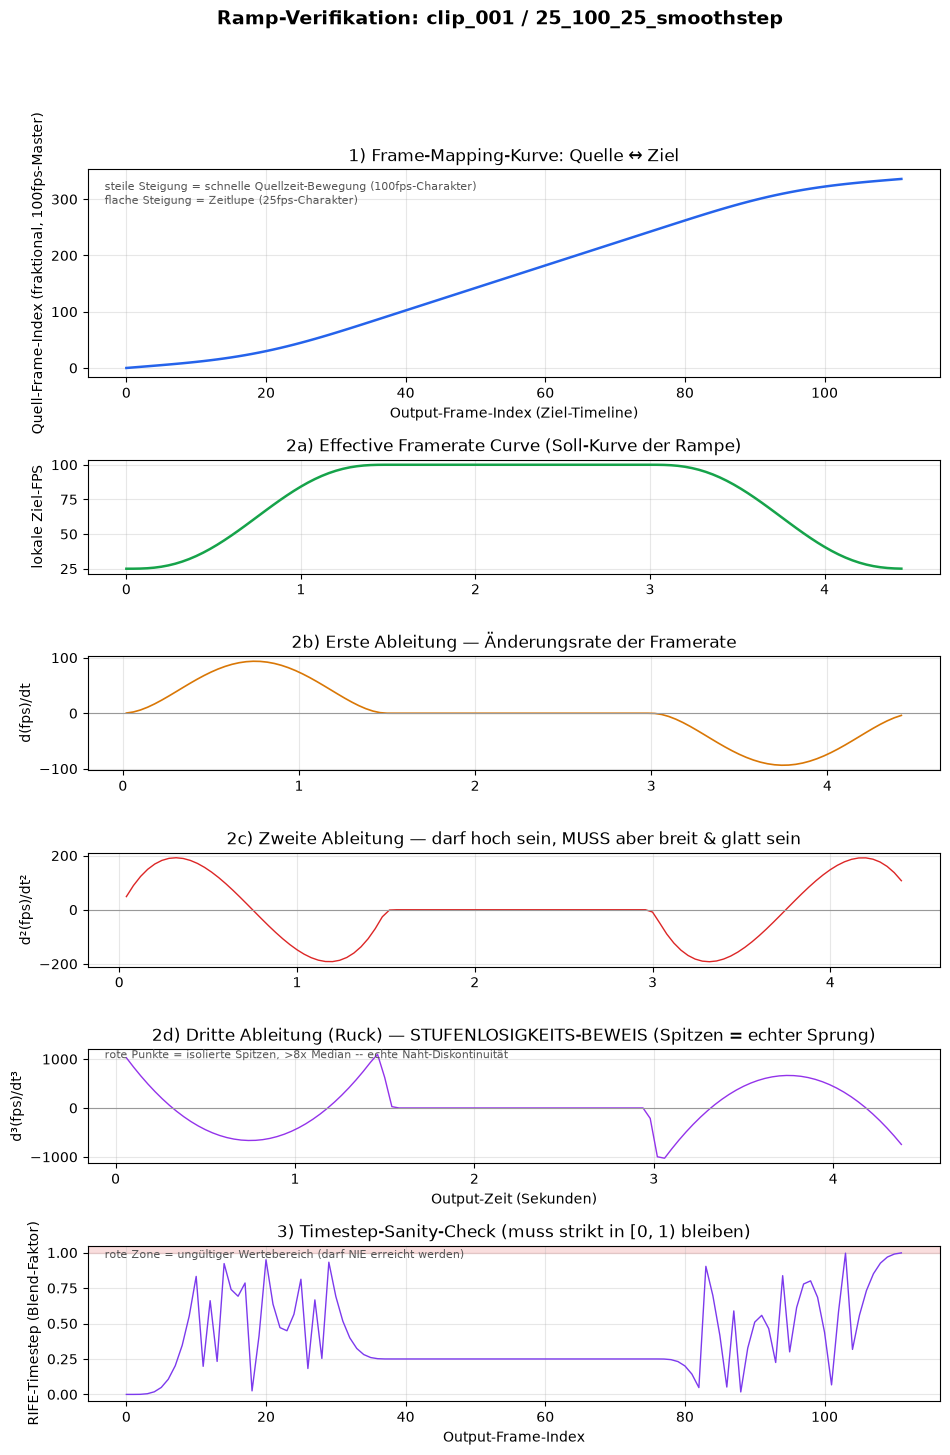

In [7]:
fig = build_full_verification_figure(
    timing_df,
    title=f"Ramp-Verifikation: {CLIP_ID} / {PRESET_NAME}",
)

plot_path = interim_dir / "verification_plot.png"
save_and_show(fig, output_path=str(plot_path), show=True)

## 5) Freigabe-Entscheidung

Erst wenn diese Zelle `True` ausgibt UND der Plot visuell unauffällig ist (keine roten Spitzen in Panel 2d, kein Erreichen der roten Zone in Panel 3), zu Schritt 8 (voller RIFE-Durchlauf) übergehen.

In [8]:
if all_passed:
    print("✅ Render-Freigabe: Alle automatisierten Prüfungen bestanden.")
    print("   Zusätzlich den Plot oben visuell gegenprüfen, dann weiter zu Schritt 8.")
else:
    print("❌ KEINE Freigabe: Mindestens eine Prüfung ist fehlgeschlagen.")
    print("   Ursache in der Konsolenausgabe oben beheben, dieses Notebook erneut ausführen.")

✅ Render-Freigabe: Alle automatisierten Prüfungen bestanden.
   Zusätzlich den Plot oben visuell gegenprüfen, dann weiter zu Schritt 8.
